First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
# locate the root folder
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive/'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

from argparse import Namespace
import time
import sys
import pprint
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(".")
sys.path.append("..")

# from datasets import augmentations
from utils.common import tensor2im, log_input_image
from models.psp import pSp
from models.pcsp import pCSp
from models.stylegan2_regular import MappingNetwork_cs, MappingNetwork_cs_shared

from notebooks.def_jupyt_funcs import load_folder_images, transform_images_to_batch, visulize_singleImg_paired4
# %load_ext autoreload
# %autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive


/home/ids/yuhe/anaconda3/envs/styleganenv/lib/python3.12/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/home/ids/yuhe/anaconda3/envs/styleganenv/lib/python3.12/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


## Parameters setting

Fell free to change the golobal parameters for all experiments

In [2]:
EXPERIMENT_PARMS = {
        # "model_orn_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pretrained_models/e4e_models/e4e_ffhq_encode.pt",
        "model_pSp_path": "../pretrained_models/pSp_models/pSp_ffhq_encode.pt",
        "model_orn_path": "./results/adjust_loss_fn/nmlp12/compare_orn/checkpoints/iteration_80000.pt",
        "model_new_path": "./results/adjust_loss_fn/nmlp12/compare_orn/checkpoints/best_model.pt",
        "images_bg_path" : "../eval_images/test_bg_imgs/", 
        "images_t_path" : "../eval_images/test_t_imgs/", 
        "model_output_size" : 1024,
        "transform": transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]) 
}

#results/opt_shared_csmlp/netSep_mse_adam_lr001_pSploss_nmlp12
# ./results/opt_csmlp/netSep_mse_adam_lr001_nmlp8
# ./results/opt_csmlp/netSep_mse_adam_lr001_pSploss_nmlp8

#results/opt_csmlp_adjust/Sep_nmlp12_mse_adam_lr001/lpips2.0_id0.5_l22.0
# ./results/opt_csmlp/netSep_mse_adam_lr001_pSploss_nmlp4
# ./results/opt_csmlp/netSep_mse_adam_lr001_pSploss_nmlp8
# ./results/opt_csmlp/netSep_mse_adam_lr001_pSploss_nmlp12
#results/opt_csmlp_adjust/Sep_nmlp12_mse_adam_lr001/improve_pSploss

Here we define some functions that will be used in the following experiments.

# Experiment 1: Inversion / Image reconstruction

In this experiment, we'll test the effect of the pretained StyleGAN inversion model (pSp with Style) for GAN inversion/reconstruction. We will first test it on several images sampled from CelebA, CelebA-HQ, CelebAMask-HQ datasets, and then, we will then test it on images collected from the internet as used in the pSp jupyter notebooks. 

### Set parameters

In [3]:
#pSp_ckpt_path = EXPERIMENT_PARMS['model_pSp_path']
model_orn_path = EXPERIMENT_PARMS['model_orn_path']
model_new_path = EXPERIMENT_PARMS['model_new_path']

image_bg_paths = EXPERIMENT_PARMS["images_bg_path"]
image_t_paths = EXPERIMENT_PARMS["images_t_path"]

transform = EXPERIMENT_PARMS['transform']


In [4]:
# def __load_latent_avg(ckpt, repeat=None):
#     if 'latent_avg' in ckpt:
#         latent_avg = ckpt['latent_avg'].to(opts.device)
#         if repeat is not None:
#             latent_avg = latent_avg.repeat(repeat, 1)
#     else:
#         latent_avg = None

In [5]:
# from configs.paths_config import model_paths
# from models.encoders import pcsp_encoders
# encoder = pcsp_encoders.GradualConstructiveStyleEncoder(50, 'ir_se', opts)

# print('Loading encoders weights from irse50!')
# encoder_ckpt = torch.load(model_paths['ir_se50'], weights_only=True)
# # if input to encoder is not an RGB image, do not load the input layer weights
# if opts.label_nc != 0:
#     print()
#     encoder_ckpt = {k: v for k, v in encoder_ckpt.items() if "input_layer" not in k}
# encoder.load_state_dict(encoder_ckpt, strict=False)



In [6]:
# ckpt = torch.load(opts.stylegan_weights)
# #self.decoder.load_state_dict(ckpt['g_ema'], strict=False)
# if opts.learn_in_w:
#     __load_latent_avg(ckpt, repeat=1)
# else:
#     __load_latent_avg(ckpt, repeat=opts.n_styles)

In [7]:


cspSp_ckpt = torch.load(model_orn_path, map_location='cpu', weights_only=True)
opts = cspSp_ckpt['opts']
opts = Namespace(**opts)

opts.pSp_checkpoint_path = None
pSp_net  = pSp(opts)
pSp_net.eval()
pSp_net.cuda()

opts.pCSp_checkpoint_path = None
pCSp_net = pCSp(opts)
pCSp_net.eval()
pCSp_net.cuda()
# pSp_net_init  = pSp(opts)

Loading encoders weights from irse50!
Loading decoder weights from pretrained!


/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive/models/psp.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(self.opts.styl

Loading encoders weights from irse50!


/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive/models/pcsp.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(self.opts.sty

pCSp(
  (encoder): GradualConstructiveStyleEncoder(
    (input_layer): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=64)
    )
    (body): Sequential(
      (0): bottleneck_IR_SE(
        (shortcut_layer): MaxPool2d(kernel_size=1, stride=2, padding=0, dilation=1, ceil_mode=False)
        (res_layer): Sequential(
          (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (2): PReLU(num_parameters=64)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): SEModule(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
           

### Visualize test images

Function vislize_folder_imgs() will show all images opened from 'test_image_folder', and also return a list 'images_list' where each element 'images_list[i] is a single 256x256 'Image' object 

In [8]:
%matplotlib inline
images_bg= load_folder_images(image_bg_paths)
input_images_bg = transform_images_to_batch(images_bg, transform)
images_t= load_folder_images(image_t_paths)
input_images_t = transform_images_to_batch(images_t, transform)
#visulize_images_batch(input_images, axis_dim=0)

In [9]:
with torch.no_grad():
    recon_pSp_bg, codes_pSp, latent_pSp_bg = pSp_net.forward(input_images_bg.to("cuda").float(), return_latents=True, return_codes=True)
    # recon_pSp_t, latent_pSp_t = pSp_net.forward(input_images_t.to("cuda").float(), return_latents=True)
    codes_bg_c, codes_bg_s, latents_bg = pCSp_net.forward(input_images_bg.to("cuda").float())

    # recon_bg_c = pSp_net.forward(codes_bg_s, input_code=True, randomize_noise=True, recon_modle=True)
    recon_bg_s = pSp_net.forward(codes_bg_s, input_code=True, randomize_noise=True, recon_modle=True)
    recon_bg_cs = pSp_net.forward(latents_bg, input_code=True, randomize_noise=True, recon_modle=True)
    #recon_t = pSp_net.forward(latent_t_c + latent_t_s, input_code=True, randomize_noise=True, recon_modle=True)	


    

### Perform encode and decode for inversion

In [10]:
# batched_input shape: bs x 3 x w x h

# recon_pSp_bg, recon_pSp_t, recon_bg, recon_t, recon_bg_swap, recon_t_swap = \
#     perform_results_using_latent_pSp(csmlp_net, pSp_net, input_images_bg, input_images_t)

# _, _, recon_bg_new, recon_t_new, recon_bg_swap_new, recon_t_swap_new = \
#     perform_results_using_latent_pSp(csmlp_new_net, pSp_net_new, input_images_bg, input_images_t)


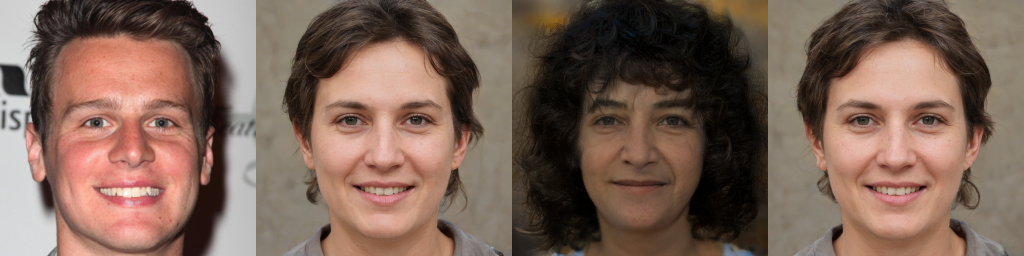

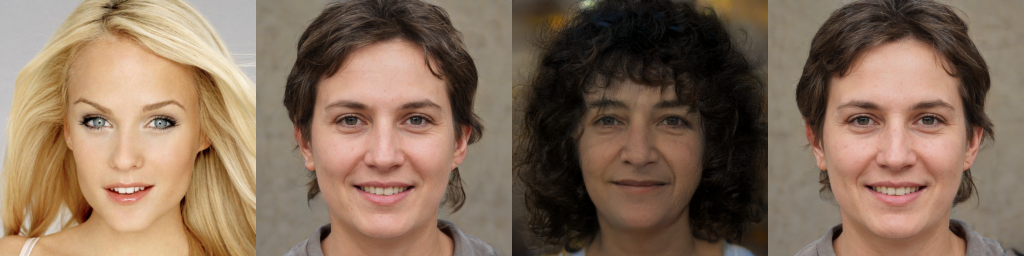

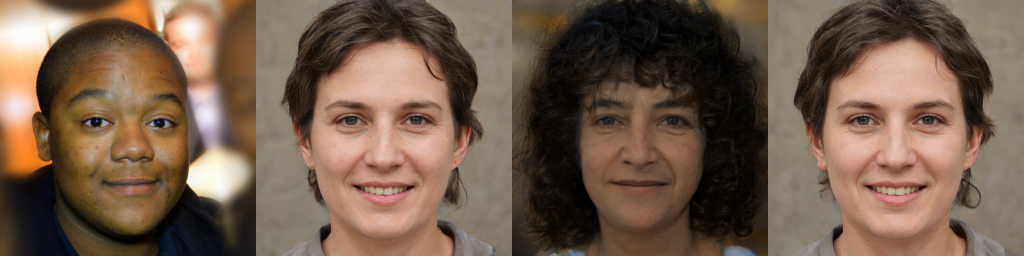

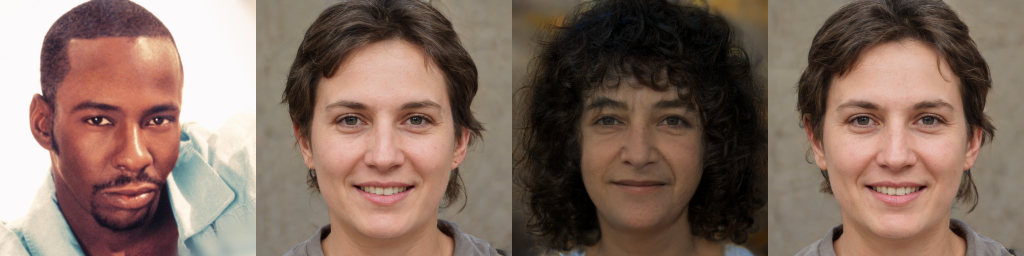

In [11]:

# # visulize_images_batch(recon_t, axis_dim=1)
n_images = recon_pSp_bg.shape[0]
for i in range (n_images):
    visulize_singleImg_paired4(input_images_bg[i,:,:,:], recon_pSp_bg[i,:,:,:], recon_bg_s[i,:,:,:], recon_bg_cs[i,:,:,:])

# for i in range (n_images):
#     visulize_singleImg_paired4(input_images_t[i,:,:,:], recon_pSp_t[i,:,:,:], recon_t[i,:,:,:], recon_t_new[i,:,:,:]) 

In [12]:
# nmlp 12

# Step - 65000, 
# {'loss_cs': {'loss_sbg': 0.003537291161483154, 'loss_ld_bg': 0.4138847686052322, 'loss_ld_t': 0.3041048957109451, 'loss': 0.721526957988739}, 
#  'loss_bg_pSp': {'loss_id': 0.3783326872587204, 'id_improve': -0.3783326839655638, 'loss_l2': 0.07954515235126018, 'loss_lpips': 0.2515990377664566, 'loss': 0.31865765631198884}, 
#  'loss_t_pSp': {'loss_id': 0.30928232657909394, 'id_improve': -0.30928232288360596, 'loss_l2': 0.07383863507211208, 'loss_lpips': 0.23994594687223433, 'loss': 0.2967236288189888}, 'loss_sum': 1.3369082431197166}

# nmlp 4
# Step - 65000, 
# {'loss_cs': {'loss_sbg': 0.00576385728828609, 'loss_ld_bg': 0.29586662822961807, 'loss_ld_t': 0.17903819692134856, 'loss': 0.4806686841249466}, 
#  'loss_bg_pSp': {'loss_id': 0.26230289751291275, 'id_improve': -0.2623028928041458, 'loss_l2': 0.061586830481886866, 'loss_lpips': 0.21315874910354615, 'loss': 0.2583441231250763}, 
#  'loss_t_pSp': {'loss_id': 0.22389548939466478, 'id_improve': -0.22389548426866532, 'loss_l2': 0.05917962092161179, 'loss_lpips': 0.20747100841999053, 'loss': 0.247545980155468}, 'loss_sum': 0.986558787405491}
